In [4]:
import importlib
import core_tools as ct

importlib.reload(ct)

<module 'core_tools' from 'd:\\Amsterdam Uni\\BEE\\2026\\Coding\\core_tools.py'>

In [5]:
# List format: ('column_name_in_csv', dictionary_from_core_tools)
variables_to_analyze = [
    ('imker_methode', ct.imker_methode_dict),
    ('winter_food', ct.winter_food_dict),
    ('varroa_treatment', ct.varroa_treatment_dict),
    ('aziatische_hoornaar', ct.aziatische_hoornaar_dict),
    #('deformed_wings',ct.deformed_wings_dict),
    ('varroa_observation',ct.varroa_observation_dict)
]

In [9]:
from itertools import combinations # 引入用于生成两两组合的工具
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def single_var(df_clean):
    for col, mapping_dict in variables_to_analyze:
        
        # --- 1. GENERATE SUMMARY TABLE ---
        summary_table = ct.winter_mortality_user_input_by_group(df_clean, col, mapping_dict=mapping_dict)
        
        print(f"============================================================")
        print(f"ANALYSIS: {col.replace('_', ' ').upper()}")
        print(f"============================================================")
        display(summary_table) 
        #summary_table.to_csv(f'outputs/appendix_table_single_variable_{col}.csv', index=False)
        
        # --- 2. GLOBAL CHI-SQUARE TEST ---
        grouped = df_clean.groupby(col)[['2025_winter_in', '2026_winter_uit']].sum()
        grouped['Died'] = grouped['2025_winter_in'] - grouped['2026_winter_uit']
        
        contingency_table = grouped[['2026_winter_uit', 'Died']]
        chi2_stat, global_p_value, dof, expected = chi2_contingency(contingency_table)
        
        # --- 3. DRAW THE CHART ---
        plt.figure(figsize=(8, 4))
        bars = plt.bar(summary_table[col].astype(str), summary_table['mortality_rate_%'], color='#2C6B8E')
        
        plt.title(f'Winter Mortality Rate by {col.replace("_", " ").title()}', fontsize=14, pad=15)
        plt.ylabel('Mortality Rate (%)', fontsize=12)
        plt.xlabel('Category', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        
        for bar in bars:
            yval = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontsize=10)

        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show() 
        
        # --- 4. PRINT STAT CONCLUSION & PAIRWISE TEST (English Version) ---
        print("\n--- 1. Global Chi-Square Test ---")
        print(f"Global P-Value: {global_p_value:.5f}")
        
        if global_p_value < 0.05:
            print("✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.\n")
            
            print("--- 2. Pairwise Comparisons (Post-hoc) ---")
            groups = contingency_table.index.tolist()
            pairs = list(combinations(groups, 2)) 
            
            bonferroni_alpha = 0.05 / len(pairs)
            print(f"💡 Statistical Rigor: Because we are making {len(pairs)} pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < {bonferroni_alpha:.4f}\n")
            
            for g1, g2 in pairs:
                table_2x2 = contingency_table.loc[[g1, g2]]
                stat, p_val, _, _ = chi2_contingency(table_2x2)
                
                label1 = mapping_dict.get(g1, g1) if mapping_dict else g1
                label2 = mapping_dict.get(g2, g2) if mapping_dict else g2
                
                if p_val < bonferroni_alpha:
                    print(f"⭐ Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
                else:
                    print(f"   No Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
                    
        else:
            print("❌ NOT SIGNIFICANT: The differences in mortality rates between categories are likely due to random chance.")
            print("   (Pairwise comparisons are not necessary).")
        
        print("\n\n")
        

## NBV

In [ ]:
# Load the cleaned data 
df_NBV = pd.read_csv('data/imkervereniging/imkervereniging_NBV.csv')
print(f"Data loaded successfully! Total apiaries to analyze: {df_NBV.shape[0]}")

Data loaded successfully! Total apiaries to analyze: 59


C:\Users\Nora-\AppData\Local\Temp\ipykernel_16788\3583582309.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_NBV = pd.read_csv('data/imkervereniging/imkervereniging_NBV.csv')


ANALYSIS: IMKER METHODE


,imker_methode,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Controlled,112,109,3,2.68
1,Natural,34,28,6,17.65
2,Regulier,312,226,86,27.56
3,Unknown and Mixed,88,73,15,17.05


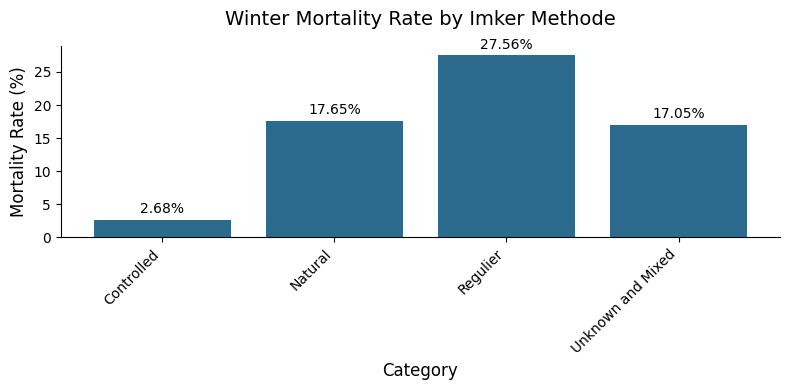


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 6 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0083

⭐ Significant Difference: Controlled vs Natural | P-Value: 0.00558
⭐ Significant Difference: Controlled vs Regulier | P-Value: 0.00000
⭐ Significant Difference: Controlled vs Unknown and Mixed | P-Value: 0.00106
   No Significant Difference: Natural vs Regulier | P-Value: 0.29905
   No Significant Difference: Natural vs Unknown and Mixed | P-Value: 1.00000
   No Significant Difference: Regulier vs Unknown and Mixed | P-Value: 0.06190



ANALYSIS: WINTER FOOD


,winter_food,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Sugar,203,137,66,32.51
1,Mixed,322,286,36,11.18
2,Honey,21,13,8,38.10


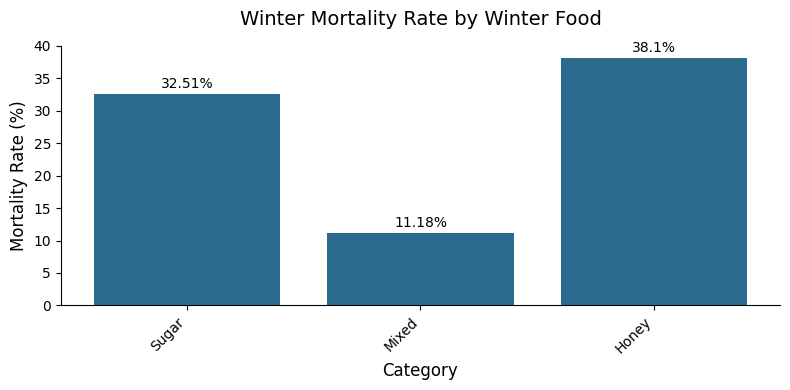


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 3 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0167

⭐ Significant Difference: Sugar vs Mixed | P-Value: 0.00000
   No Significant Difference: Sugar vs Honey | P-Value: 0.78398
⭐ Significant Difference: Mixed vs Honey | P-Value: 0.00121



ANALYSIS: VARROA TREATMENT


,varroa_treatment,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,3 gangenmenu full treatment,315,243,72,22.86
1,alternatieve behandeling,31,27,4,12.90
2,alleen in the winter,15,12,3,20.00
3,alleen in the zomer,97,75,22,22.68
4,Nee,88,79,9,10.23


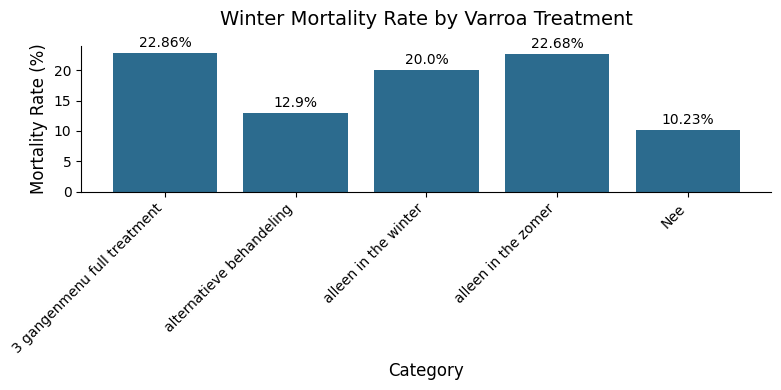


--- 1. Global Chi-Square Test ---
Global P-Value: 0.08388
❌ NOT SIGNIFICANT: The differences in mortality rates between categories are likely due to random chance.
   (Pairwise comparisons are not necessary).



ANALYSIS: AZIATISCHE HOORNAAR


,aziatische_hoornaar,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Nee,292,208,84,28.77
1,Weinig,74,61,13,17.57
2,Matig,30,29,1,3.33
3,Veel,150,138,12,8.00


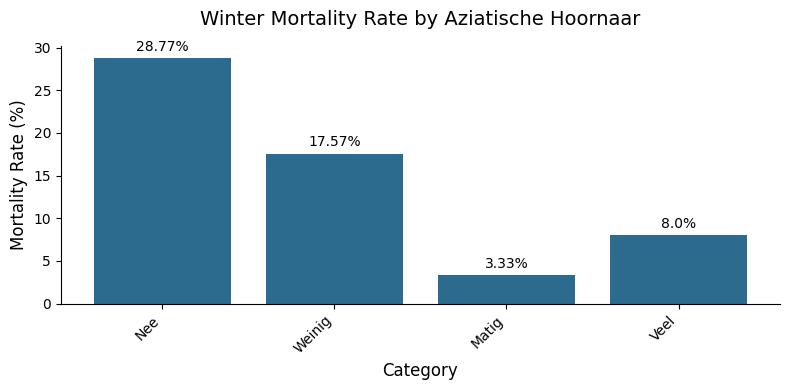


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 6 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0083

   No Significant Difference: Nee vs Weinig | P-Value: 0.07149
⭐ Significant Difference: Nee vs Matig | P-Value: 0.00524
⭐ Significant Difference: Nee vs Veel | P-Value: 0.00000
   No Significant Difference: Weinig vs Matig | P-Value: 0.10745
   No Significant Difference: Weinig vs Veel | P-Value: 0.05571
   No Significant Difference: Matig vs Veel | P-Value: 0.60649



ANALYSIS: VARROA OBSERVATION


,varroa_observation,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Nee,38,36,2,5.26
1,Weinig,140,125,15,10.71
2,Matig,279,194,85,30.47
3,Veel,41,36,5,12.20
4,Weet het niet,48,45,3,6.25


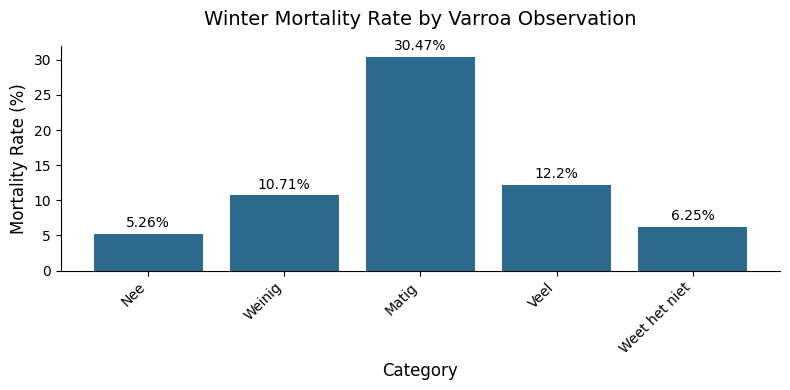


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 10 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0050

   No Significant Difference: Nee vs Weinig | P-Value: 0.48220
⭐ Significant Difference: Nee vs Matig | P-Value: 0.00212
   No Significant Difference: Nee vs Veel | P-Value: 0.49203
   No Significant Difference: Nee vs Weet het niet | P-Value: 1.00000
⭐ Significant Difference: Weinig vs Matig | P-Value: 0.00001
   No Significant Difference: Weinig vs Veel | P-Value: 1.00000
   No Significant Difference: Weinig vs Weet het niet | P-Value: 0.53337
   No Significant Difference: Matig vs Veel | P-Value: 0.02486
⭐ Significant Difference: Matig vs Weet het niet | P-Value: 0.00091
   No Signifi

In [10]:
single_var(df_NBV)